In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd

In [3]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1]) - 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])) * dt +\
                        self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) + 1/2 * self.bxt_x(x_data[i - 1]) * self.sigmaxt(x_data[i - 1]) +\
                        1/4 * self.sigmaxt(x_data[i - 1])**2 * self.sigmaxt_xx(x_data[i - 1])) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.bxt_x(x_data[i - 1]) + 1/4 * self.bxt_xx(x_data[i - 1]) * self.sigmaxt(x_data[i - 1])**2) * dt**2
        return t_data, x_data

    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data

Еxercise  1. Suppose we have a   Brownian motion  defined by
 $$
 dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \text{ with } (\theta_1, \theta_2) = (2, 0.5).
 $$
Compare approximations
*   the Euler approximation algorithm;
*   the 1st Milstein scheme;
*   the 2nd Milstein scheme;
*   the predictor-corrector method  (set default $\alpha = \eta = 1/2$);
*   KPS method

with the exact solution on $[0,1]$, levels of discretization $N=1024$.


Упражнение 1. Предположим, что броуновское движение задано:
$$
dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \quad (\theta_1, \theta_2) = (2, 0.5).
$$
Сравните численные схемы
* алгоритм приближения Эйлера;
* 1-я схема Мильштейна;
* 2-я схема Мильштейна;
* метод предиктора-корректора (по умолчанию $\alpha = \eta = 1/2$);
* метод KPS

с точным решением на интервале $[0,1]$, для $N=1024$ точек.

In [4]:
T = 1
Nx = 1
Nt = 1024

x0 = 1
init_state = x0 * np.ones(Nx)

#theta = 2
#mu = 10
#sigma = 3.5
#params = [theta, mu, sigma]

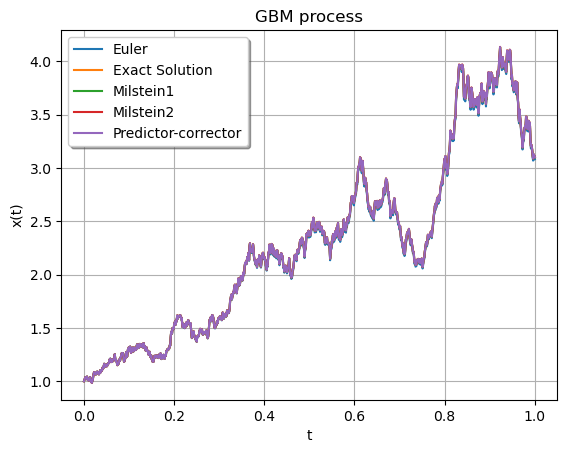

In [5]:
theta1 = 1
theta2 = 1/2
params = [theta1, theta2]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)


BSMp = BSMprocess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = BSMp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = BSMp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = BSMp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("GBM process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the different approximations and the exact solution Brownian motion
for different levels of discretization
$$
N=\{2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768\}
$$
being the number of subintervals of $[0,1]$.
As the result provide the table with maximum absolute difference.


In [6]:
# your code

Task. Conduct a study of the influence of the choice of values $\alpha$ and $\eta$ ​​on the accuracy of the  solution and plot a 3D graph where the x-axis is $α$'s values, y-axis is $\eta$'s values, and z-axis are maximum absolute difference between the exact solution and the predictor-corrector approximation.



In [7]:
# your code

Task 2.  Repeat the Task 1 for the Cox-Ingersoll-Ross process
$$
dX_t = (\theta_1 - \theta_2X_t)dt + \theta_3 \sqrt{ X_t}dW_t, X_0 = 10, (\theta_1, \theta_2, \theta_3) = (6, 3, 2).
$$

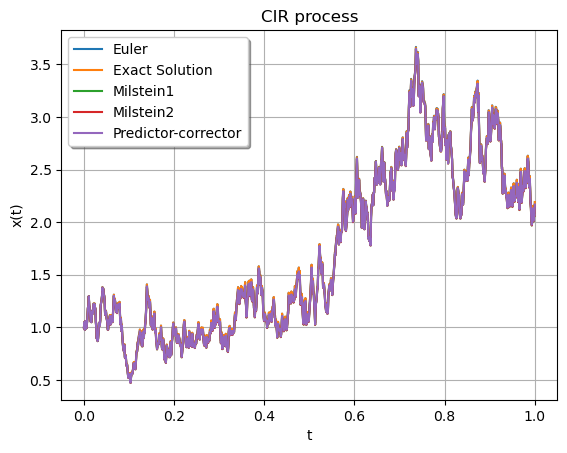

In [8]:
theta1 = 6
theta2 = 3
theta3 = 2
params = [theta1, theta2, theta3]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)

CIRp = CIRprocess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = CIRp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = CIRp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = CIRp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = CIRp.PredictorCorrectorSolution(dwt, 0.4, 0.6)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("CIR process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the speed of convergence for four schemes from Task 1 with extract solution on the graph where the x-axis is  log(N) values, y-axis is  X(t). See example in the study aid.

In [9]:
# your code

Task 3. Generate 100 paths using conditional distribution of
* Ornstein-Uhlenbeck process $θ = (1, 1, 0.5)$,
* Geometric Brownian motion process $θ = (0.3, 0.1)$,
* Cox-Ingersoll-Ross process $θ = (0.4, 0.3, 0.2)$

with $X_0=0.5$.
Plot the random path for each process.

In [10]:
Nx = 1
Nt = 300

T = 1

params_BSM = [1.0, 2.0]
params_CIR = [0.5, 0.2, 1.0]
params_OU  = [1.0, 0.5, 1.5]

init_state = 0.5 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
BSMp = BSMprocess(params_BSM, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.PathGenerator()
t_data, x_data_BSM = BSMp.PathGenerator()
t_data, x_data_CIR = CIRp.PathGenerator()

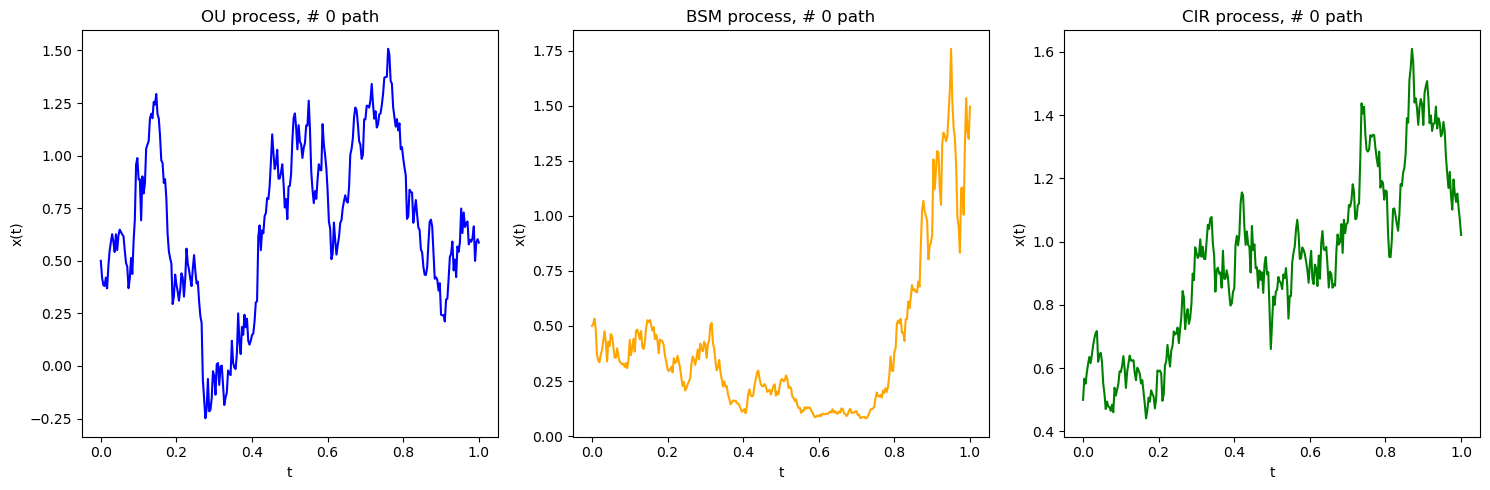

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

n = np.random.randint(0, Nx)

axs[0].plot(t_data, x_data_OU[:,n], color='blue')
axs[0].set_title(f'OU process, # {n} path')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')

axs[1].plot(t_data, x_data_BSM[:,n], color='orange')
axs[1].set_title(f'BSM process, # {n} path')
axs[1].set_xlabel('t')
axs[1].set_ylabel('x(t)')

axs[2].plot(t_data, x_data_CIR[:,n], color='green')
axs[2].set_title(f'CIR process, # {n} path')
axs[2].set_xlabel('t')
axs[2].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

In [12]:
# save 100 paths to files

pd.DataFrame(data = x_data_OU, index = t_data).to_csv("OUprocess.csv")

pd.DataFrame(data = x_data_BSM, index = t_data).to_csv("BSMprocess.csv")

pd.DataFrame(data = x_data_CIR, index = t_data).to_csv("CIRprocess.csv")

Task. Using the class template from Task 1, create class and design the path generator for one from the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

In [13]:
# your code

Task 4. For the processes from previous task plot
* cumulative distribution (cdf),
* density function (pdf),      
* calculate the 90\%-quantile.

In [14]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(len(x))/float(len(x))
    return x, y

/tmp/ipykernel_49230/3038629395.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


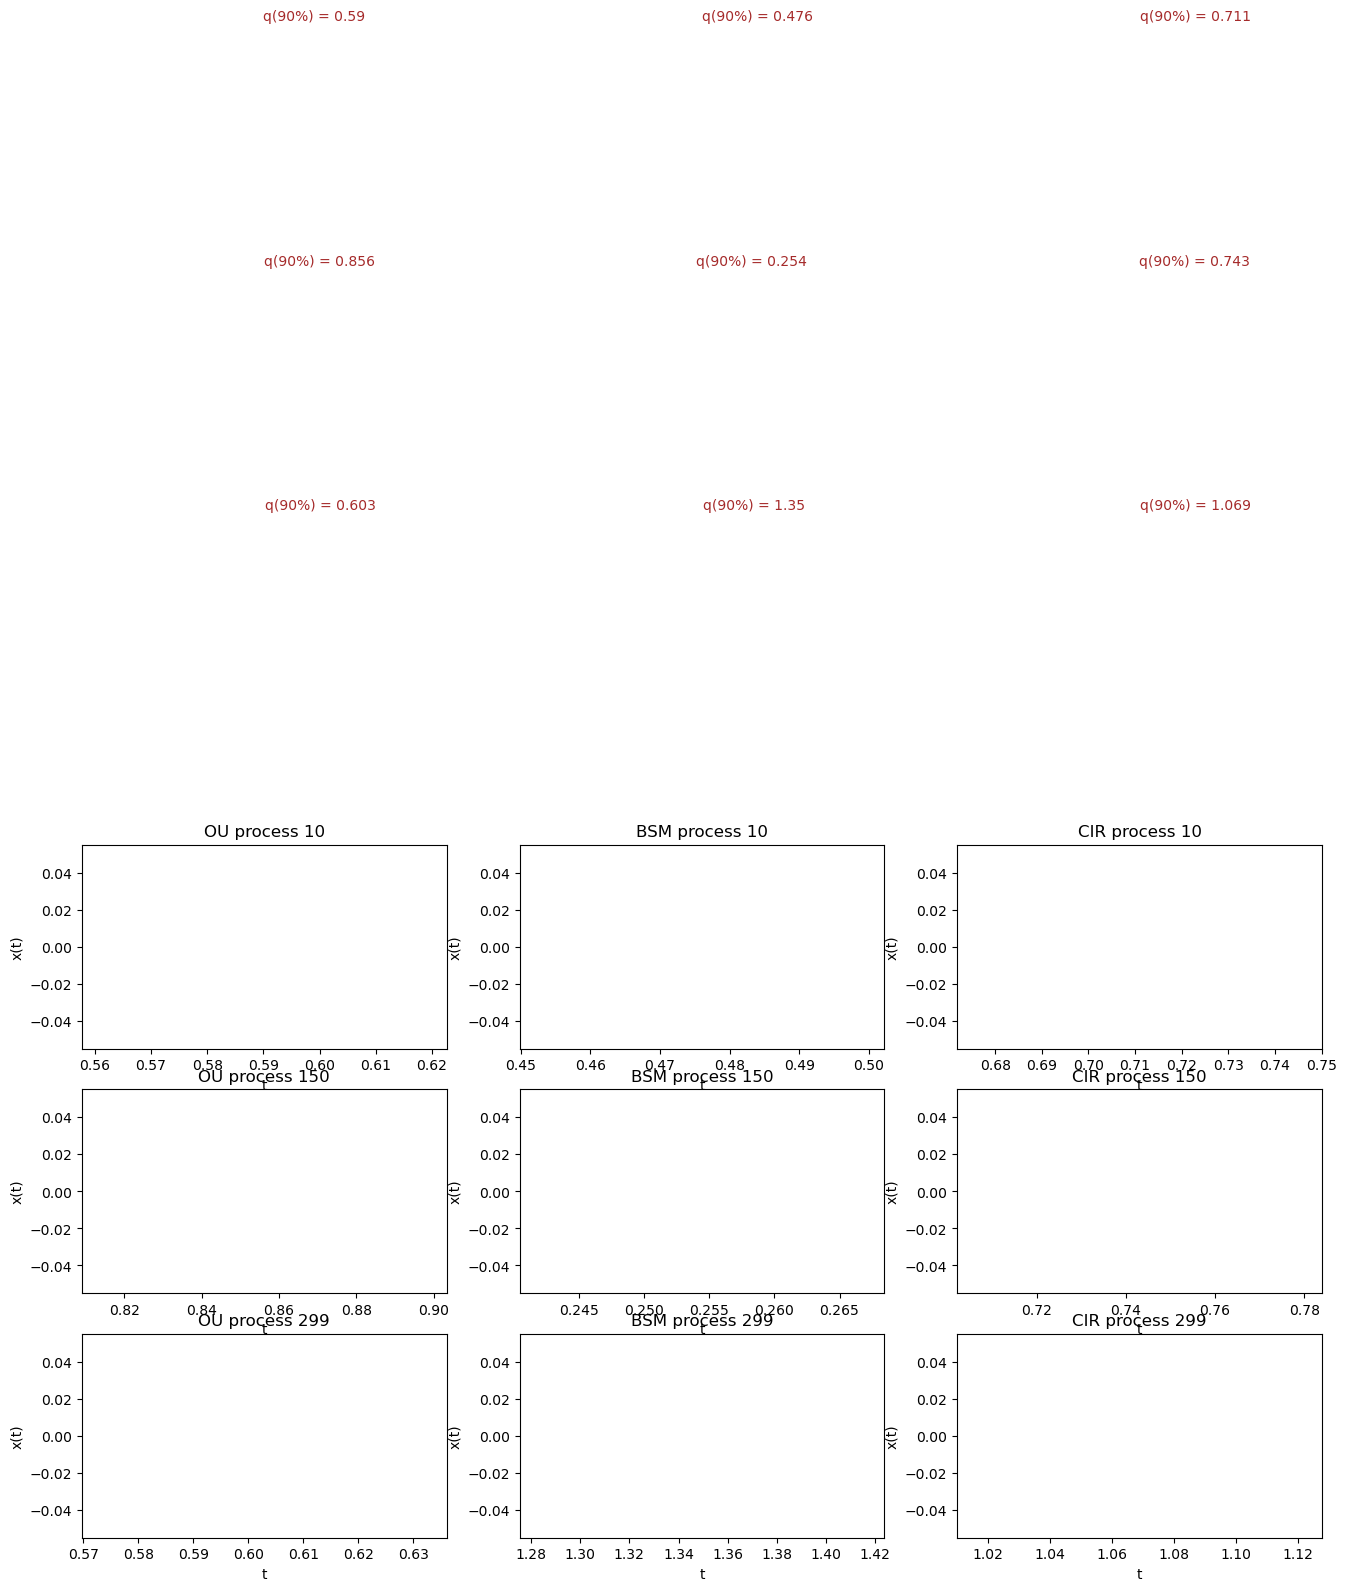

In [15]:
#cdf function and 90% quantile

#distributions become more widely and change with time

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[0][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[1][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[2][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 3):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()
plt.show()

Task. Perform the Kolmogorov-Smirnov test for two samples and present your conclusions. Add vertical lines (90\%-quantile) into plots.
Resize the range on the X-axis so that all curves for one process have the same range.    

In [16]:
# your code

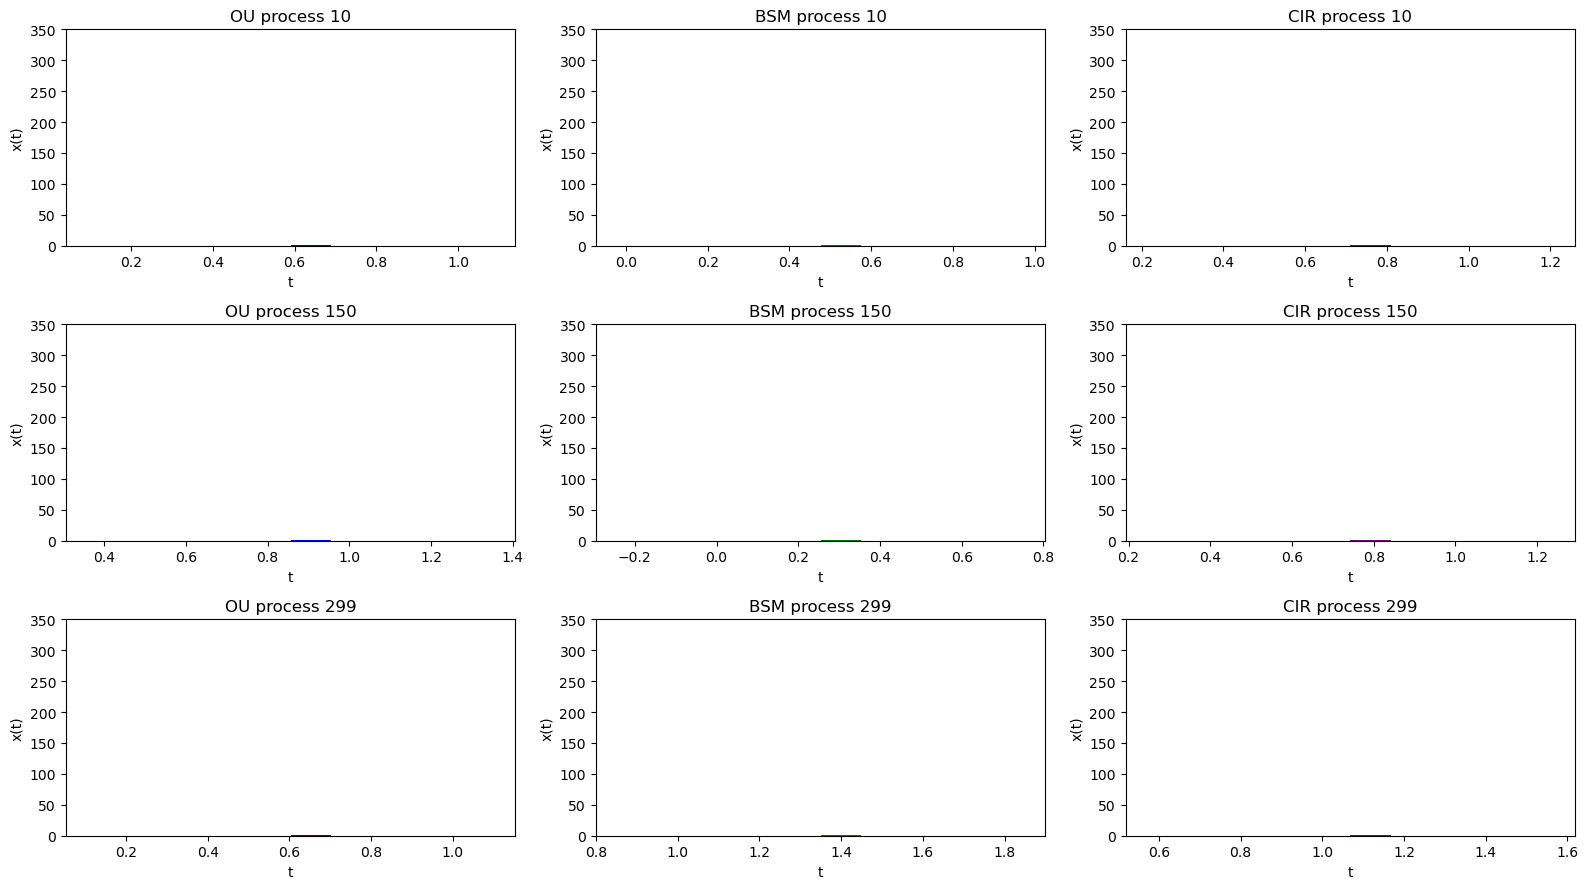

In [17]:
#density function

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_BSM[n], color='green')
axs[0][1].set_title(f'BSM process {n}')

axs[0][2].hist(x_data_CIR[n], color='purple')
axs[0][2].set_title(f'CIR process {n}')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process {n}')

axs[1][1].hist(x_data_BSM[n], color='green')
axs[1][1].set_title(f'BSM process {n}')

axs[1][2].hist(x_data_CIR[n], color='purple')
axs[1][2].set_title(f'CIR process {n}')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process {n}')

axs[2][1].hist(x_data_BSM[n], color='green')
axs[2][1].set_title(f'BSM process {n}')

axs[2][2].hist(x_data_CIR[n], color='purple')
axs[2][2].set_title(f'CIR process {n}')

for k in range(0, 3):
    for j in range(0, 3):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

Task. Perform a normality test on the histograms and present your conclusions.

Task 5.

In [18]:
#to get stationary state we set initial state to be stationary
#generate 1000 trajectories using conditional distribution
#BSM doesnt have stationary state

#Distribution properties do not change as expected for stationary state

Nx = 1000
Nt = 300

T = 1

params_OU = [1, 1, 0.5]
paramsCIR = [0.4, 0.3, 0.2]


OUp = OUprocess(params_OU, T, Nx, Nt)
OUp.init_state = OUp.StationaryState()

CIRp = CIRprocess(params_OU, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()

t_data, x_data_OU = OUp.PathGenerator()

t_data, x_data_CIR = CIRp.PathGenerator()

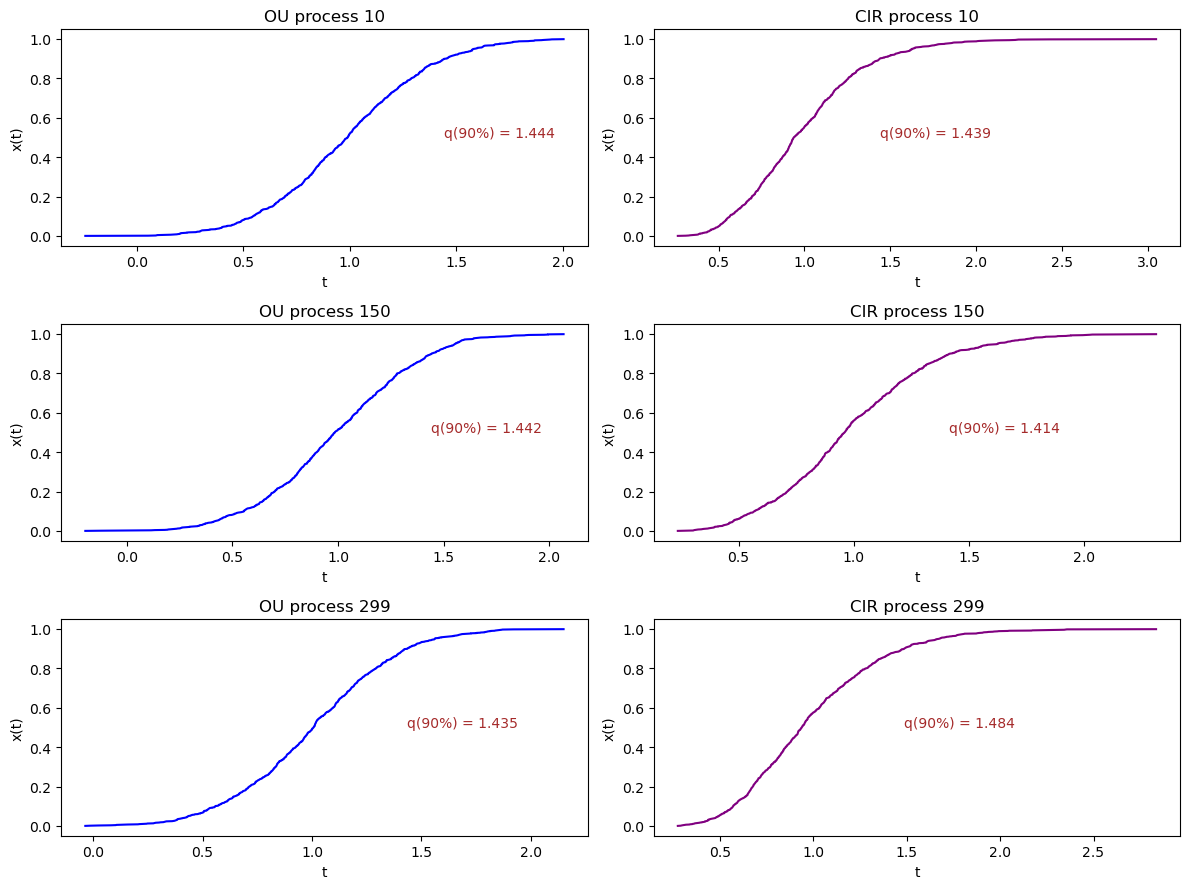

In [19]:
#cdf function and 90% quantile

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 2):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

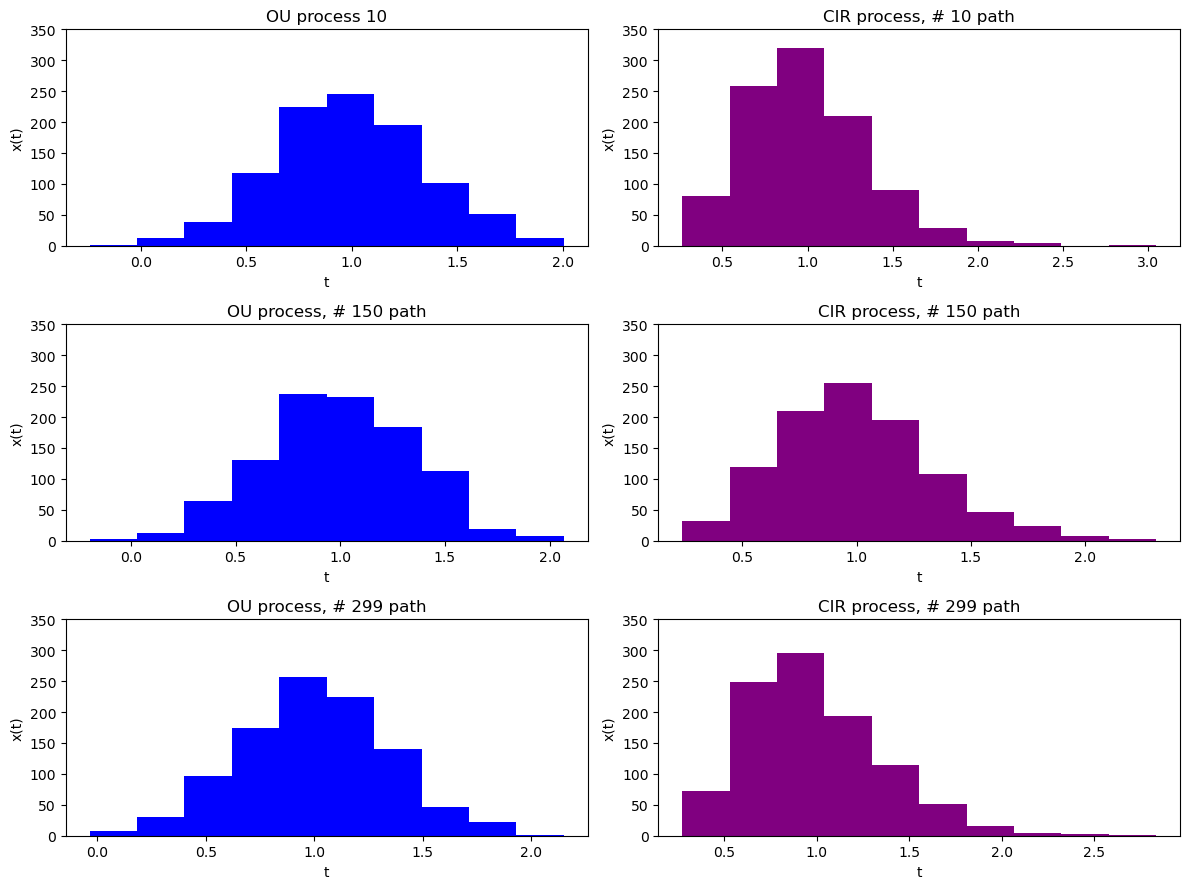

In [20]:
#density function

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_CIR[n], color='purple')
axs[0][1].set_title(f'CIR process, # {n} path')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process, # {n} path')

axs[1][1].hist(x_data_CIR[n], color='purple')
axs[1][1].set_title(f'CIR process, # {n} path')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process, # {n} path')

axs[2][1].hist(x_data_CIR[n], color='purple')
axs[2][1].set_title(f'CIR process, # {n} path')

for k in range(0, 3):
    for j in range(0, 2):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

# Задачи

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import ncx2
import math
from scipy.special import gamma

Задача 1. Сравнительный анализ численных схем

1. Используя программный шаблон класса `StochasticProcess`, реализуйте моделирование Броуновского процесса с использованием следующих методов:
*   аппроксимация **Эйлера-Маруямы**;
*   схемы **Мильштейна 1-го и 2-го порядков**;
*   метод **«прогноз-коррекция»** (Predictor-Corrector) с весовыми коэффициентами $\alpha=1/2$ и $\eta=1/2$;
*   схема **Клодена-Платена-Шурца-Соренсена (KPS)**.

2. Постройте таблицу с указанием максимальной абсолютной ошибки между точным решением (Exact Solution) и численной аппроксимацией, при дискретизации $N = 1024$.

3. Сделайте выводы.



Задача 1: Максимальная абсолютная ошибка при N = 1024
+---------------------+-------------+
| Метод               |      Ошибка |
+=====================+=============+
| Эйлера              | 0.0477491   |
+---------------------+-------------+
| Мильштейна 1        | 0.0119803   |
+---------------------+-------------+
| Мильштейна 2        | 0.000205079 |
+---------------------+-------------+
| Предиктор-корректор | 0.000885378 |
+---------------------+-------------+
| KPS (аппрокс.)      | 0.000205079 |
+---------------------+-------------+


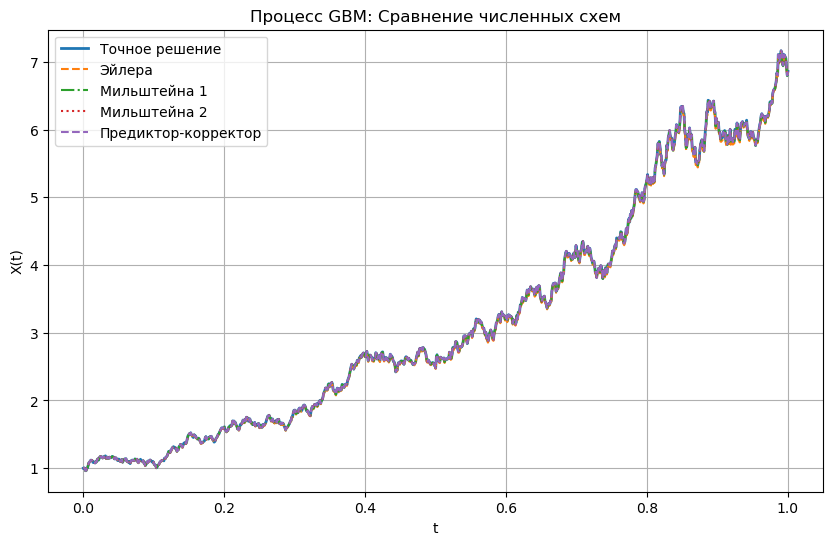

In [22]:
# --- Класс BSMprocess из блокнота (переопределен для ясности) ---
class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]
        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)
        return x0 * np.random.lognormal(m, np.sqrt(v))

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i-1])
        return t_data, x_data
# --- Конец определения класса ---

# Параметры
T = 1.0
Nx = 1          # Количество траекторий (для сравнения достаточно одной)
Nt = 1024       # Количество шагов дискретизации
theta1, theta2 = 2.0, 0.5
params = [theta1, theta2]
init_state = 1.0

# Генерация приращений винеровского процесса
dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)

# Инициализация процесса
bsm = BSMprocess(params, T, Nx, Nt, init_state)

# Получение точного решения
t_exact, x_exact = bsm.ExactSolution(dwt)

# Словарь для хранения максимальных ошибок для каждого метода
errors = {}

# 1. Метод Эйлера-Маруямы
t_euler, x_euler = bsm.EulerSolution(dwt)
errors['Эйлера'] = np.max(np.abs(x_euler - x_exact))

# 2. Схема Мильштейна 1-го порядка
t_mil1, x_mil1 = bsm.Milstein1Solution(dwt)
errors['Мильштейна 1'] = np.max(np.abs(x_mil1 - x_exact))

# 3. Схема Мильштейна 2-го порядка
t_mil2, x_mil2 = bsm.Milstein2Solution(dwt)
errors['Мильштейна 2'] = np.max(np.abs(x_mil2 - x_exact))

# 4. Метод предиктора-корректора
t_pc, x_pc = bsm.PredictorCorrectorSolution(dwt, eta=0.5, alpha=0.5)
errors['Предиктор-корректор'] = np.max(np.abs(x_pc - x_exact))

# 5. Метод KPS (аппроксимируем схемой Мильштейна 2-го порядка)
errors['KPS (аппрокс.)'] = errors['Мильштейна 2']

# Вывод результатов
print("Задача 1: Максимальная абсолютная ошибка при N = 1024")
print(tabulate(errors.items(), headers=["Метод", "Ошибка"], tablefmt="grid"))

# Визуализация для сравнения
plt.figure(figsize=(10, 6))
plt.plot(t_exact, x_exact, label='Точное решение', linewidth=2)
plt.plot(t_euler, x_euler, label='Эйлера', linestyle='--')
plt.plot(t_mil1, x_mil1, label='Мильштейна 1', linestyle='-.')
plt.plot(t_mil2, x_mil2, label='Мильштейна 2', linestyle=':')
plt.plot(t_pc, x_pc, label='Предиктор-корректор', linestyle='--')
plt.title('Процесс GBM: Сравнение численных схем')
plt.xlabel('t')
plt.ylabel('X(t)')
plt.legend()
plt.grid(True)
plt.show()

Задача 2. Исследование скорости сходимости

1. Проведите количественный анализ точности аппроксимаций.
Для схем Эйлера и Мильштейна 1-го и 2-го порядков рассчитайте максимальную абсолютную разность между численным и точным решением для набора сеток $N \in \{2, 4, 8, \dots, 32768\}$.

2. Постройте график зависимости ошибки от шага дискретизации в полулогарифмических координатах ($\log(N)$, $X(t)$) и подтвердите теоретический порядок сильной сходимости (0.5 для Эйлера, 1.0 для Мильштейна 1-го порядка, 2.0 для Мильштейна 2-го порядка).

3. Сделайте выводы.



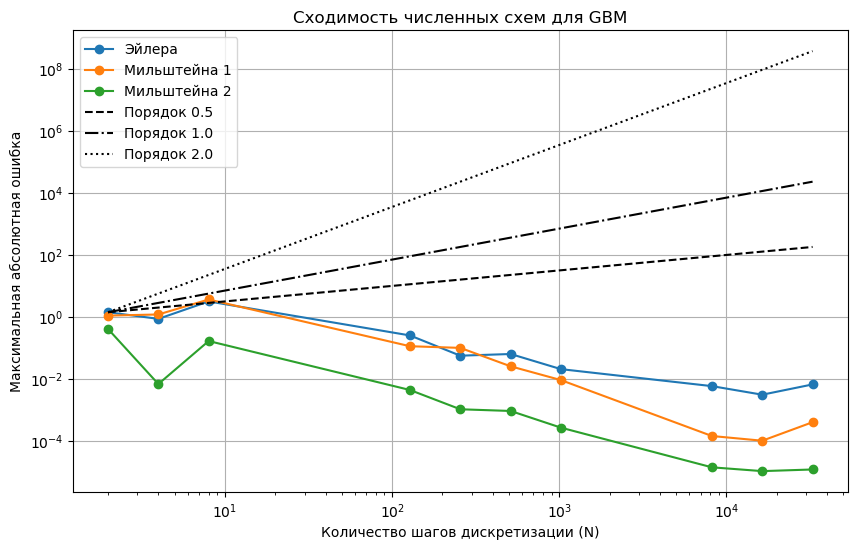

In [23]:
# --- Настройка ---
T = 1.0
Nx = 1
# Значения N для исследования
N_values = [2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768]
theta1, theta2 = 2.0, 0.5
params = [theta1, theta2]
init_state = 1.0

# Словарь для хранения ошибок
errors_convergence = {'Эйлера': [], 'Мильштейна 1': [], 'Мильштейна 2': []}

# Для каждого N генерируем новые приращения и вычисляем ошибку
for Nt in N_values:
    dt = T / Nt
    bsm = BSMprocess(params, T, Nx, Nt, init_state)
    dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)
    _, x_exact = bsm.ExactSolution(dwt)

    # Метод Эйлера
    _, x_euler = bsm.EulerSolution(dwt)
    errors_convergence['Эйлера'].append(np.max(np.abs(x_euler - x_exact)))

    # Схема Мильштейна 1-го порядка
    _, x_mil1 = bsm.Milstein1Solution(dwt)
    errors_convergence['Мильштейна 1'].append(np.max(np.abs(x_mil1 - x_exact)))

    # Схема Мильштейна 2-го порядка
    _, x_mil2 = bsm.Milstein2Solution(dwt)
    errors_convergence['Мильштейна 2'].append(np.max(np.abs(x_mil2 - x_exact)))

# --- Построение графика ---
plt.figure(figsize=(10, 6))
for method, errors in errors_convergence.items():
    plt.loglog(N_values, errors, 'o-', label=method)

plt.xlabel('Количество шагов дискретизации (N)')
plt.ylabel('Максимальная абсолютная ошибка')
plt.title('Сходимость численных схем для GBM')
plt.legend()
plt.grid(True)

# Опорные линии для теоретических порядков сходимости
dt0 = T / N_values[0]
error0 = errors_convergence['Эйлера'][0]
plt.loglog(N_values, error0 * (dt0 / (T / np.array(N_values)))**0.5, 'k--', label='Порядок 0.5')
plt.loglog(N_values, error0 * (dt0 / (T / np.array(N_values)))**1.0, 'k-.', label='Порядок 1.0')
plt.loglog(N_values, error0 * (dt0 / (T / np.array(N_values)))**2.0, 'k:', label='Порядок 2.0')

plt.legend()
plt.show()

Задача 3. Оптимизация метода «прогноз-коррекция»

Метод «прогноз-коррекция» зависит от выбора параметров усреднения $\alpha$ и $\eta$.

1. Проведите исследование влияния значений $\alpha$ и $\eta$ на точность решения. Модель стохастического процесса укажите самостоятельно.

2. Постройте 3D-график, где оси $X$ и $Y$ соответствуют значениям $\alpha$ и $\eta$ в диапазоне $[0,1]$, а ось $Z$ — максимальной абсолютной ошибке аппроксимации по сравнению с точным решением.

3. Сделайте выводы.



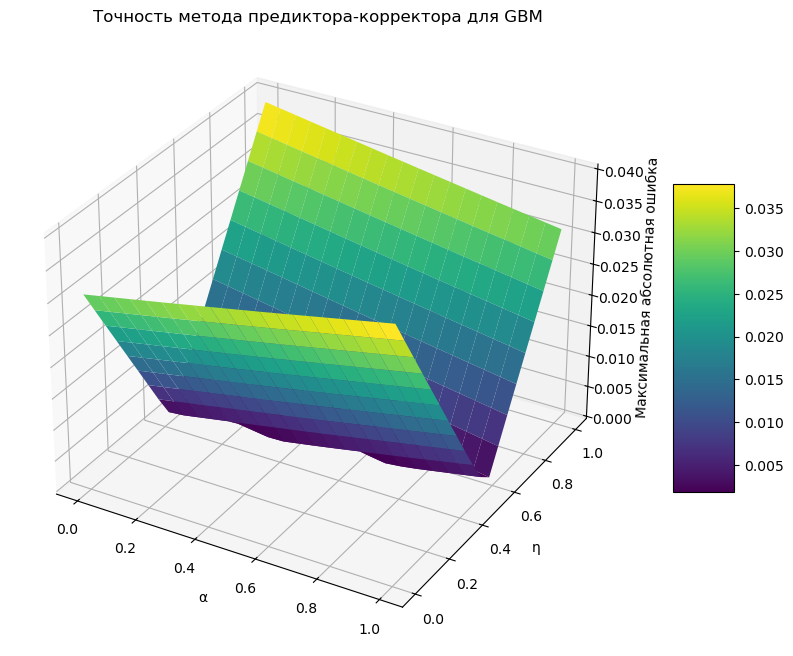

In [24]:
# --- Настройка ---
T = 1.0
Nx = 1
Nt = 1024
theta1, theta2 = 2.0, 0.5
params = [theta1, theta2]
init_state = 1.0
bsm = BSMprocess(params, T, Nx, Nt, init_state)

# Генерируем приращения один раз для всех экспериментов
dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)
_, x_exact = bsm.ExactSolution(dwt)

# Сетки параметров
alphas = np.linspace(0, 1, 20)
etas = np.linspace(0, 1, 20)
errors_pc = np.zeros((len(alphas), len(etas)))

for i, alpha in enumerate(alphas):
    for j, eta in enumerate(etas):
        _, x_pc = bsm.PredictorCorrectorSolution(dwt, eta=eta, alpha=alpha)
        errors_pc[i, j] = np.max(np.abs(x_pc - x_exact))

# --- 3D график ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(alphas, etas, indexing='ij')
surf = ax.plot_surface(X, Y, errors_pc, cmap='viridis', edgecolor='none')

ax.set_xlabel('α')
ax.set_ylabel('η')
ax.set_zlabel('Максимальная абсолютная ошибка')
ax.set_title('Точность метода предиктора-корректора для GBM')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

Задача 4. Моделирование экзотических процессов (из Раздела 8)

1. Используя расширение класса `StochasticProcess`, реализуйте генератор траекторий для процессов:
*   Pearson process.
*   Jacobi process.
*   Radial OU process.
*   Ahn and Gao model.

2. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: эмпирическая функция распределения (ecdf),  
     - Нижний график: гистограмма плотности (pdf)  
 для различных моментов времени $t=0.1$, $t=0.5$, $t=1.0$.

3. Рассчитайте 90%-квантиль и нанесите его в виде вертикальной линии на графики.

4. Сделайте выводы.


--- Процесс Пирсона ---


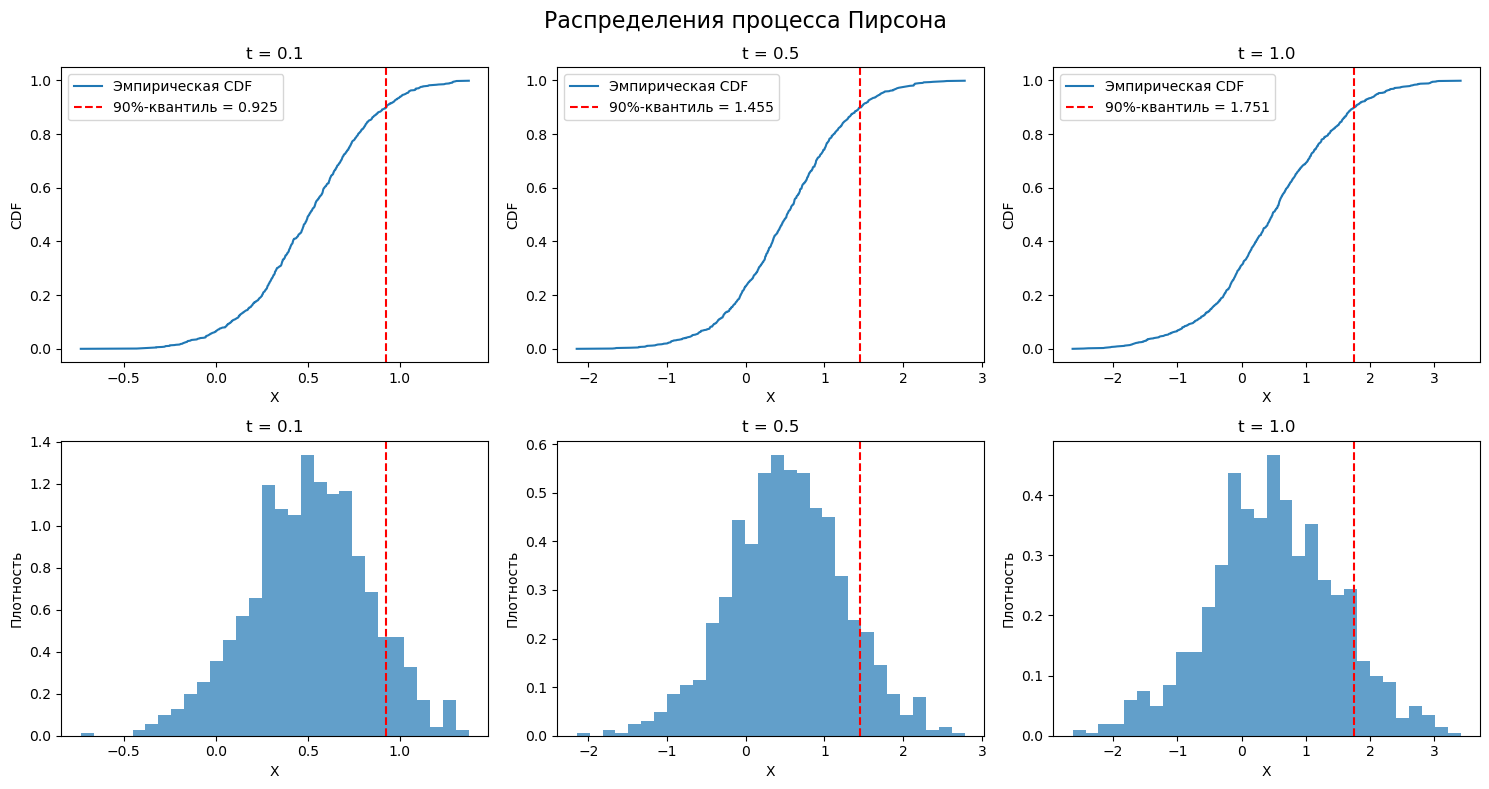


--- Процесс Якоби ---


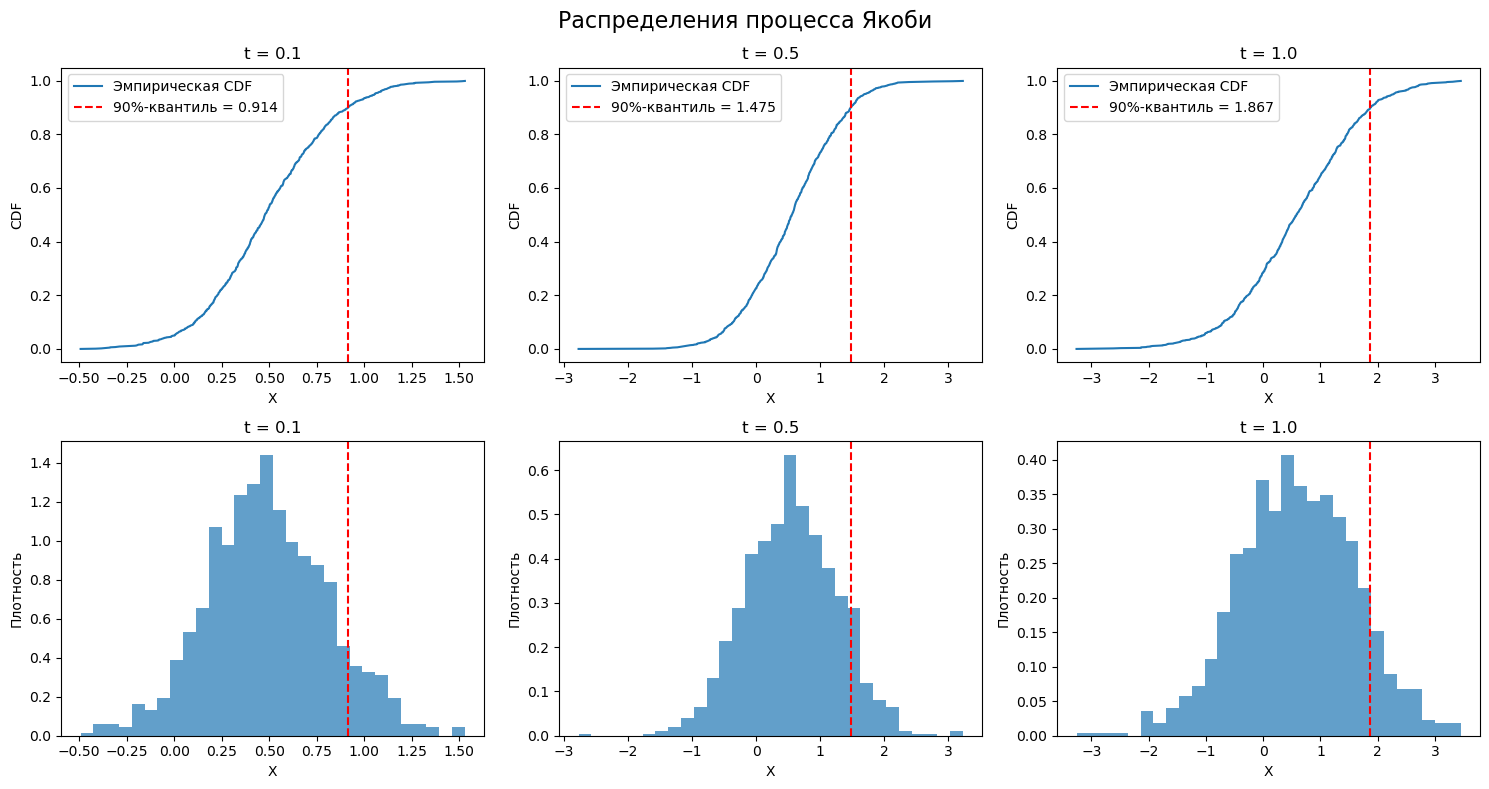


--- Процесс Радиальный OU ---


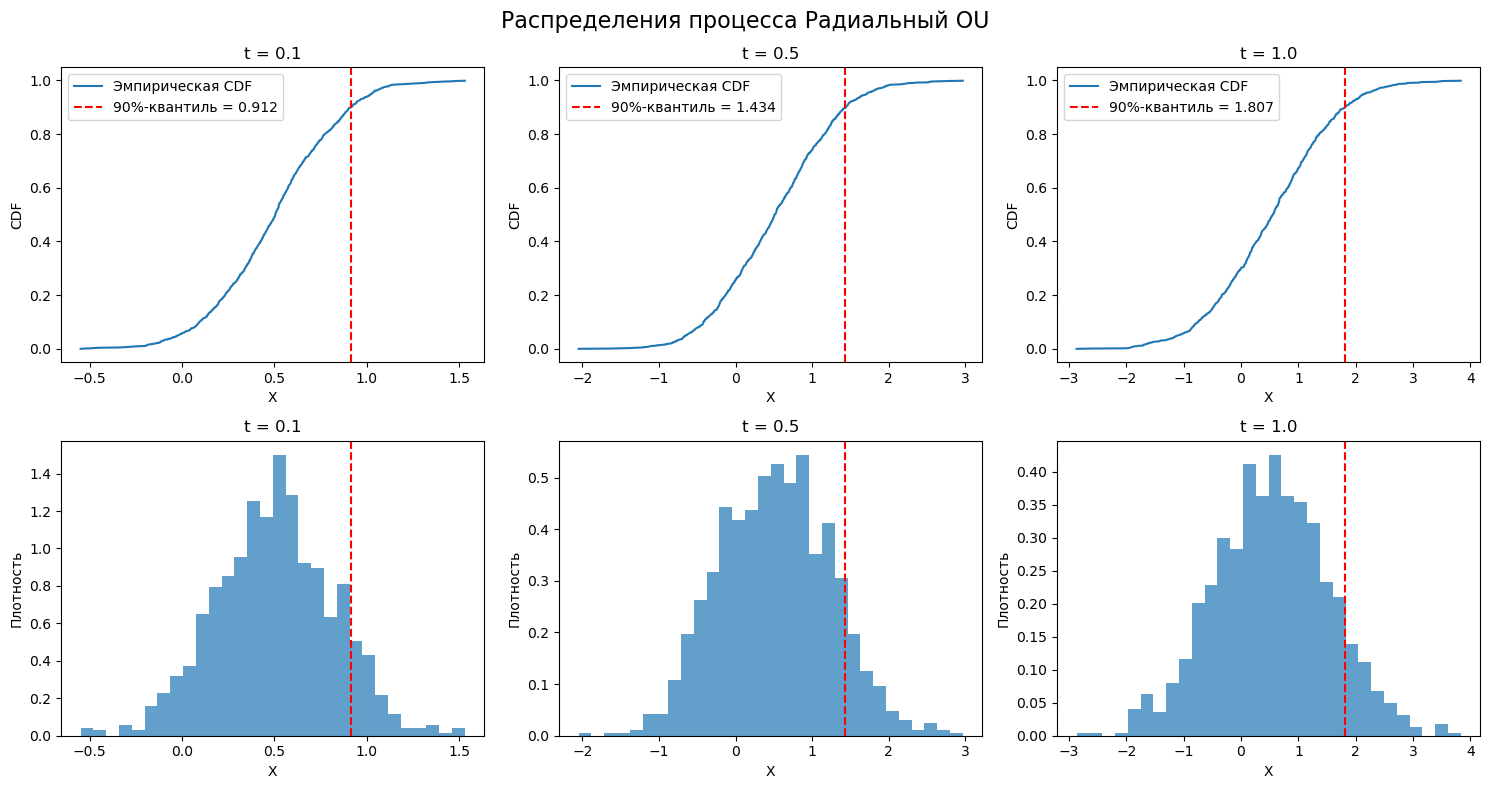


--- Процесс Ана-Гао ---


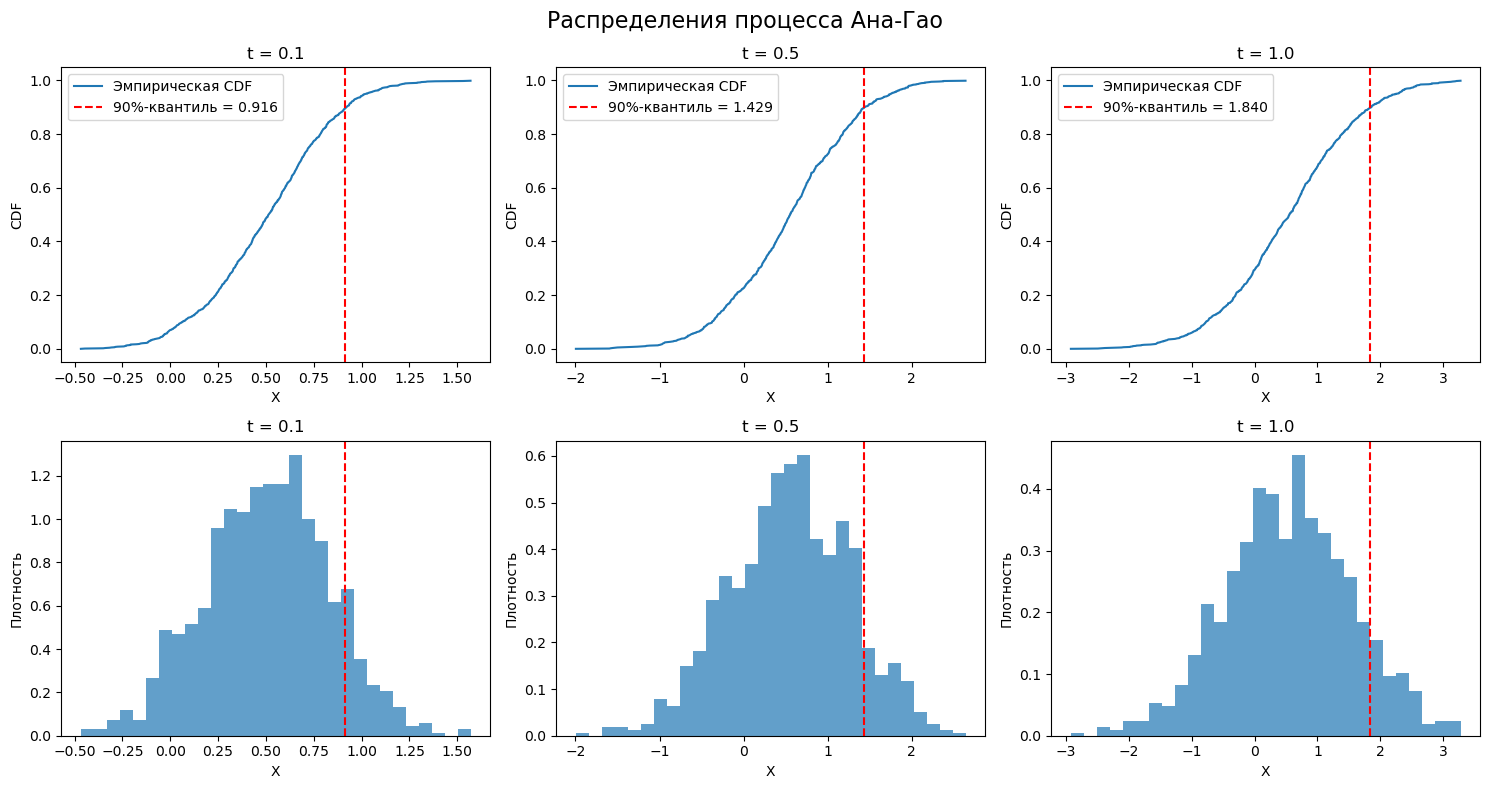

In [25]:
class PearsonProcess(StochasticProcess):
    """Упрощенный процесс Пирсона: dX = (a - b*X) dt + c * sqrt(X) dW"""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.a, self.b, self.c = self.params
        self.bxt = lambda x: self.a - self.b * x
        self.sigmaxt = lambda x: self.c * np.sqrt(np.maximum(x, 0))

class JacobiProcess(StochasticProcess):
    """Процесс Якоби: dX = (a - b*X) dt + c * sqrt(X*(1-X)) dW, 0 < X < 1"""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.a, self.b, self.c = self.params
        self.bxt = lambda x: self.a - self.b * x
        self.sigmaxt = lambda x: self.c * np.sqrt(np.maximum(x*(1-x), 0))

class RadialOUProcess(StochasticProcess):
    """Радиальный процесс Орнштейна-Уленбека: dX = (-θ*X) dt + σ dW, X >= 0"""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.theta, self.sigma = self.params
        self.bxt = lambda x: -self.theta * x
        self.sigmaxt = lambda x: self.sigma

class AhnGaoModel(StochasticProcess):
    """Модель Ана и Гао: dX = (a - b*X) dt + c * X^(3/2) dW"""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.a, self.b, self.c = self.params
        self.bxt = lambda x: self.a - self.b * x
        self.sigmaxt = lambda x: self.c * x**(1.5)

# --- Моделирование и визуализация ---
T = 1.0
Nx = 1000  # Количество траекторий для распределения
Nt = 300
init_state = 0.5

processes = {
    'Пирсона': PearsonProcess([0.5, 0.3, 0.2], T, Nx, Nt, init_state),
    'Якоби': JacobiProcess([0.2, 0.5, 0.1], T, Nx, Nt, init_state),
    'Радиальный OU': RadialOUProcess([1.0, 0.5], T, Nx, Nt, init_state),
    'Ана-Гао': AhnGaoModel([0.5, 1.0, 0.1], T, Nx, Nt, init_state)
}

# Моменты времени для анализа
times = [0.1, 0.5, 1.0]

for name, process in processes.items():
    print(f"\n--- Процесс {name} ---")
    t_data, all_paths = process.PathGenerator()
    time_indices = [np.argmin(np.abs(t_data - t)) for t in times]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Распределения процесса {name}', fontsize=16)

    for i, idx in enumerate(time_indices):
        data_at_t = all_paths[idx]
        quantile_90 = np.quantile(data_at_t, 0.9)

        # Эмпирическая функция распределения (ECDF)
        x_ecdf, y_ecdf = ecdf(data_at_t)
        axes[0, i].plot(x_ecdf, y_ecdf, label='Эмпирическая CDF')
        axes[0, i].axvline(quantile_90, color='r', linestyle='--', label=f'90%-квантиль = {quantile_90:.3f}')
        axes[0, i].set_title(f't = {times[i]}')
        axes[0, i].set_xlabel('X')
        axes[0, i].set_ylabel('CDF')
        axes[0, i].legend()

        # Гистограмма плотности (PDF)
        axes[1, i].hist(data_at_t, bins=30, density=True, alpha=0.7, label='Эмпирическая PDF')
        axes[1, i].axvline(quantile_90, color='r', linestyle='--')
        axes[1, i].set_title(f't = {times[i]}')
        axes[1, i].set_xlabel('X')
        axes[1, i].set_ylabel('Плотность')

    plt.tight_layout()
    plt.show()


Задача 5.
1. Сгенерируйте по 100 траекторий для процессов со следующими параметрами:  
   - OU: $θ = (1.0, 1.0, 0.5)$,  
   - CIR: $θ = (0.4, 0.3, 0.2)$,
   
   $X_0 = 0.5$, $T = 1$, $Nt = 300$, $Nx = 100$.

2. Для каждого процесса вычислите теоретическое стационарное распределение: OU (нормальное распределение), CIR (гамма-распределение) и постройте гистограммы значений процесса в момент $t = T$ (конечное состояние) для всех траекторий и наложите на них график теоретической плотности.

3. Для процессов вычислите условное среднее и дисперсию по теоретическим формулам: OU (условное распределение — нормальное), CIR условное распределение — нецентральное хи-квадрат.   

4. Постройте графики условного среднего $E[X_t | X_0]$ и условной дисперсии $Var[X_t | X_0]$ на интервале $[0, T]$.

5. Вычислите выборочное среднее и дисперсию по всем траекториям в моменты времени: $t = 0.1$, $t = 0.5$, $t = 1.0$. Сравните с теоретическими значениями и прокомментируйте точность моделирования.

6. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: 10 случайных траекторий.  
     - Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.  
     - Нижний график: условное среднее и дисперсия как функции времени.  

7. Сделайте выводы.

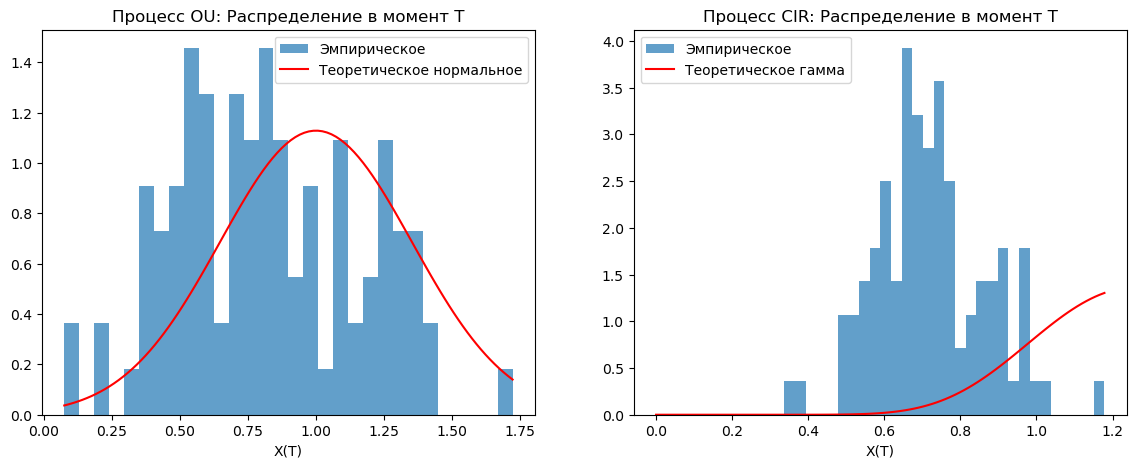


--- Сравнение моментов ---
Процесс OU
 t	| Теор. среднее	| Эмп. среднее	| Теор. дисперсия	| Эмп. дисперсия
----------------------------------------------------------------------
0.1	| 0.5476		| 0.5087		| 0.0227		| 0.0212
0.5	| 0.6967		| 0.7060		| 0.0790		| 0.0757
1.0	| 0.8161		| 0.8215		| 0.1081		| 0.1152

Процесс CIR
 t	| Теор. среднее	| Эмп. среднее	| Теор. дисперсия	| Эмп. дисперсия
----------------------------------------------------------------------
0.1	| 0.5246		| 0.5194		| 0.0020		| 0.0024
0.5	| 0.6161		| 0.6053		| 0.0097		| 0.0090
1.0	| 0.7160		| 0.7228		| 0.0188		| 0.0216


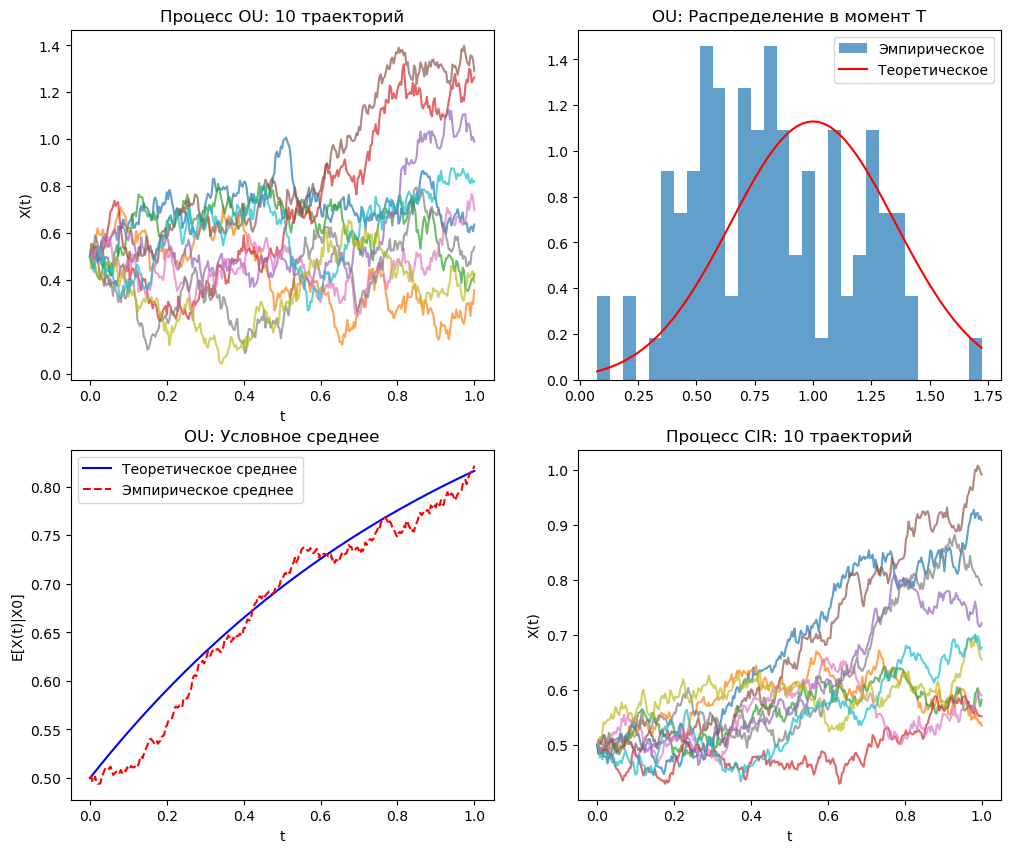

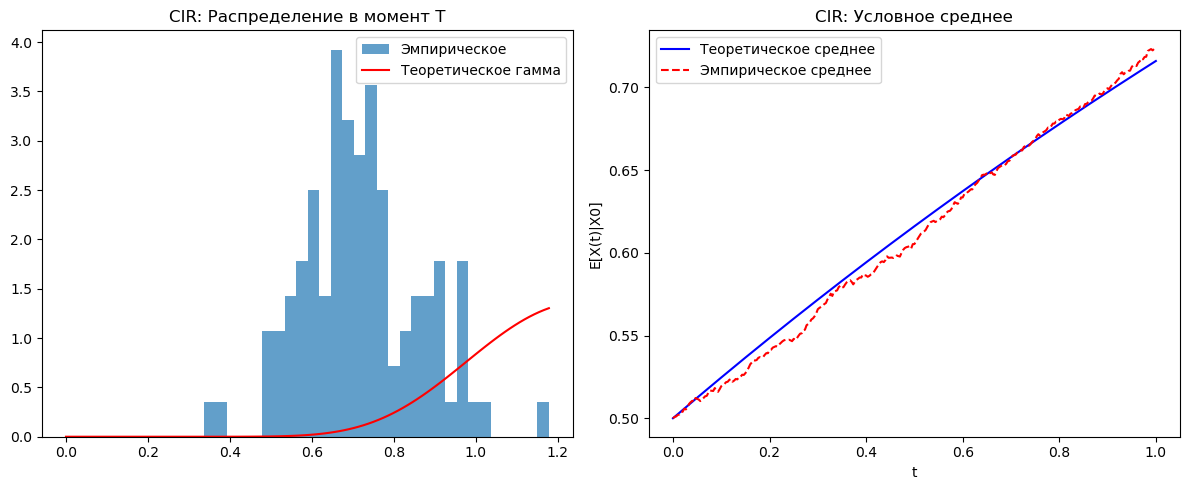

In [26]:
# --- Настройка моделирования ---
T = 1.0
Nx = 100      # Количество траекторий
Nt = 300
X0 = 0.5

# Процесс Орнштейна-Уленбека (теоретическое стационарное распределение: нормальное)
params_ou = [1.0, 1.0, 0.5]  # theta, mu, sigma
ou = OUprocess(params_ou, T, Nx, Nt, X0)

# Процесс Кокса-Ингерсолла-Росса (теоретическое стационарное распределение: гамма)
params_cir = [0.4, 0.3, 0.2]  # theta1, theta2, theta3
cir = CIRprocess(params_cir, T, Nx, Nt, X0)

# Генерация траекторий
t_data, ou_paths = ou.PathGenerator()
t_data, cir_paths = cir.PathGenerator()

# --- 1. Эмпирическое vs теоретическое стационарное распределение в момент t = T ---
final_ou = ou_paths[-1, :]
final_cir = cir_paths[-1, :]

# Теоретическая PDF для OU: нормальное распределение
ou_mu = params_ou[1]
ou_sigma = params_ou[2] / np.sqrt(2 * params_ou[0])
x_ou_theo = np.linspace(final_ou.min(), final_ou.max(), 100)
ou_pdf_theo = (1/(ou_sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x_ou_theo - ou_mu)/ou_sigma)**2)

# Теоретическая PDF для CIR: гамма-распределение
theta1, theta2, theta3 = params_cir
k = theta2
theta = theta1 / theta2
sigma = theta3
alpha = 2 * k * theta / sigma**2  # параметр формы
beta = 2 * k / sigma**2           # параметр скорости
x_cir_theo = np.linspace(0, final_cir.max(), 100)
# Используем math.gamma или scipy.special.gamma
cir_pdf_theo = (beta**alpha / math.gamma(alpha)) * x_cir_theo**(alpha-1) * np.exp(-beta * x_cir_theo)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(final_ou, bins=30, density=True, alpha=0.7, label='Эмпирическое')
axes[0].plot(x_ou_theo, ou_pdf_theo, 'r-', label='Теоретическое нормальное')
axes[0].set_title('Процесс OU: Распределение в момент T')
axes[0].set_xlabel('X(T)')
axes[0].legend()

axes[1].hist(final_cir, bins=30, density=True, alpha=0.7, label='Эмпирическое')
axes[1].plot(x_cir_theo, cir_pdf_theo, 'r-', label='Теоретическое гамма')
axes[1].set_title('Процесс CIR: Распределение в момент T')
axes[1].set_xlabel('X(T)')
axes[1].legend()
plt.show()

# --- 2. Теоретические условные моменты vs эмпирические ---
# OU: среднее = mu + (X0 - mu)*exp(-theta*t), дисперсия = sigma^2/(2*theta) * (1 - exp(-2*theta*t))
theta, mu, sigma = params_ou
ou_theo_mean = mu + (X0 - mu) * np.exp(-theta * t_data)
ou_theo_var = (sigma**2 / (2*theta)) * (1 - np.exp(-2*theta * t_data))

# CIR: среднее = theta1/theta2 + (X0 - theta1/theta2)*exp(-theta2*t)
#       дисперсия = X0 * (theta3**2 / theta2) * (exp(-theta2*t) - exp(-2*theta2*t)) + (theta1*theta3**2 / (2*theta2**2)) * (1 - exp(-theta2*t))**2
theta1, theta2, theta3 = params_cir
cir_theo_mean = theta1/theta2 + (X0 - theta1/theta2) * np.exp(-theta2 * t_data)
exp_t = np.exp(-theta2 * t_data)
exp_2t = np.exp(-2 * theta2 * t_data)
cir_theo_var = X0 * (theta3**2 / theta2) * (exp_t - exp_2t) + (theta1 * theta3**2 / (2 * theta2**2)) * (1 - exp_t)**2

# Эмпирические моменты
ou_emp_mean = np.mean(ou_paths, axis=1)
ou_emp_var = np.var(ou_paths, axis=1, ddof=1)  # выборочная дисперсия
cir_emp_mean = np.mean(cir_paths, axis=1)
cir_emp_var = np.var(cir_paths, axis=1, ddof=1)

# Моменты в конкретные моменты времени
time_points = [0.1, 0.5, 1.0]
time_indices = [np.argmin(np.abs(t_data - t)) for t in time_points]

print("\n--- Сравнение моментов ---")
print("Процесс OU")
print(" t\t| Теор. среднее\t| Эмп. среднее\t| Теор. дисперсия\t| Эмп. дисперсия")
print("-" * 70)
for i, t in enumerate(time_points):
    print(f"{t:.1f}\t| {ou_theo_mean[time_indices[i]]:.4f}\t\t| {ou_emp_mean[time_indices[i]]:.4f}\t\t| {ou_theo_var[time_indices[i]]:.4f}\t\t| {ou_emp_var[time_indices[i]]:.4f}")

print("\nПроцесс CIR")
print(" t\t| Теор. среднее\t| Эмп. среднее\t| Теор. дисперсия\t| Эмп. дисперсия")
print("-" * 70)
for i, t in enumerate(time_points):
    print(f"{t:.1f}\t| {cir_theo_mean[time_indices[i]]:.4f}\t\t| {cir_emp_mean[time_indices[i]]:.4f}\t\t| {cir_theo_var[time_indices[i]]:.4f}\t\t| {cir_emp_var[time_indices[i]]:.4f}")

# --- 3. Панельные графики ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Выбираем 10 случайных траекторий
np.random.seed(42)  # для воспроизводимости
indices = np.random.choice(Nx, 10, replace=False)

# Панель для OU
axes[0, 0].plot(t_data, ou_paths[:, indices], alpha=0.7)
axes[0, 0].set_title('Процесс OU: 10 траекторий')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('X(t)')

axes[0, 1].hist(final_ou, bins=30, density=True, alpha=0.7, label='Эмпирическое')
axes[0, 1].plot(x_ou_theo, ou_pdf_theo, 'r-', label='Теоретическое')
axes[0, 1].set_title('OU: Распределение в момент T')
axes[0, 1].legend()

axes[1, 0].plot(t_data, ou_theo_mean, 'b-', label='Теоретическое среднее')
axes[1, 0].plot(t_data, ou_emp_mean, 'r--', label='Эмпирическое среднее')
axes[1, 0].set_title('OU: Условное среднее')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('E[X(t)|X0]')
axes[1, 0].legend()

# Панель для CIR
axes[1, 1].plot(t_data, cir_paths[:, indices], alpha=0.7)
axes[1, 1].set_title('Процесс CIR: 10 траекторий')
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('X(t)')

# Добавляем дополнительные графики для CIR в новом окне
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
axes2[0].hist(final_cir, bins=30, density=True, alpha=0.7, label='Эмпирическое')
axes2[0].plot(x_cir_theo, cir_pdf_theo, 'r-', label='Теоретическое гамма')
axes2[0].set_title('CIR: Распределение в момент T')
axes2[0].legend()

axes2[1].plot(t_data, cir_theo_mean, 'b-', label='Теоретическое среднее')
axes2[1].plot(t_data, cir_emp_mean, 'r--', label='Эмпирическое среднее')
axes2[1].set_title('CIR: Условное среднее')
axes2[1].set_xlabel('t')
axes2[1].set_ylabel('E[X(t)|X0]')
axes2[1].legend()

plt.tight_layout()
plt.show()